# 📈 Univariate Time Series Forecasting
## Australian Monthly Beer Production — Modular ARIMA Pipeline
### A Complete, Interview-Ready Analysis

---

**Dataset:** Monthly Beer Production in Australia (1956–1995), 476 observations  
**Goal:** Forecast future beer production using a clean, reproducible ARIMA pipeline  
**Pipeline:** Deseasonalise → Transform → Difference → Diagnose → Model → Evaluate → Forecast

---

## Pipeline Overview

| Step | Action | Purpose |
|------|--------|---------|
| 1 | Load & Explore | Understand the data |
| 2 | Train-Test Split | Honest evaluation |
| 3 | Deseasonalise | Remove seasonal pattern |
| 4 | Log Transform | Stabilise variance |
| 5 | Differencing | Achieve stationarity |
| 6 | Stationarity Tests | ADF confirmation |
| 7 | ACF / PACF | Identify model orders |
| 8 | Fit Multiple ARIMA Models | Candidate comparison |
| 9 | Residual Diagnostics | Validate best model |
| 10 | Variance Diagnostics | Breusch-Pagan test |
| 11 | Forecast on Test Set | Out-of-sample evaluation |
| 12 | Model Comparison Table | Select best model |


## 0 — Imports & Global Settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import warnings
warnings.filterwarnings('ignore')

# ── Consistent, professional plot style ──
plt.rcParams.update({
    'figure.dpi'           : 110,
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'axes.grid'            : True,
    'grid.alpha'           : 0.3,
    'font.size'            : 11,
    'axes.titlesize'       : 12,
    'axes.titleweight'     : 'bold',
    'figure.facecolor'     : 'white',
})

COLORS = {
    'blue'   : '#2c7bb6',
    'red'    : '#d7191c',
    'green'  : '#1a9641',
    'orange' : '#fdae61',
    'purple' : '#7b2d8b',
    'gray'   : '#636363',
}

print("✓ Libraries loaded successfully.")


✓ Libraries loaded successfully.


## Step 1 — Load & Explore the Data

We load the Australian Monthly Beer Production dataset. Before any modelling,
we visualise the raw series to understand its key characteristics.


In [2]:
def load_data(filepath, date_col, value_col, freq='MS'):
    """
    Load a time series CSV into a pandas Series with a DatetimeIndex.

    Parameters
    ----------
    filepath  : str  — Path to CSV file
    date_col  : str  — Column name containing dates
    value_col : str  — Column name containing values
    freq      : str  — Pandas frequency string (default 'MS' = month start)

    Returns
    -------
    pd.Series with DatetimeIndex
    """
    df = pd.read_csv(filepath, parse_dates=[date_col], index_col=date_col)
    series = df[value_col].asfreq(freq)
    return series


def explore_data(series, title='Time Series'):
    """
    Print basic info and plot the raw series + seasonal bar chart.

    Parameters
    ----------
    series : pd.Series — Raw time series
    title  : str       — Title for the plots
    """
    print("=" * 55)
    print(f"  DATA OVERVIEW — {title}")
    print("=" * 55)
    print(f"  Observations : {len(series)}")
    print(f"  Date range   : {series.index.min().date()} → {series.index.max().date()}")
    print(f"  Missing      : {series.isna().sum()}")
    print(f"  Mean         : {series.mean():.2f}")
    print(f"  Std          : {series.std():.2f}")
    print(f"  Min / Max    : {series.min():.2f} / {series.max():.2f}")
    print("=" * 55)

    fig, axes = plt.subplots(2, 1, figsize=(13, 7))

    # Panel 1 — Raw time series
    axes[0].plot(series, color=COLORS['blue'], linewidth=1.2)
    axes[0].set_title(f"Raw Series — {title}", fontweight='bold')
    axes[0].set_ylabel('Megalitres')
    axes[0].xaxis.set_major_locator(mdates.YearLocator(5))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Panel 2 — Average by month (reveals seasonal pattern)
    monthly_avg = series.groupby(series.index.month).mean()
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    axes[1].bar(month_names, monthly_avg.values, color=COLORS['blue'],
                edgecolor='white', width=0.7)
    axes[1].axhline(monthly_avg.mean(), color=COLORS['red'], linestyle='--',
                    linewidth=1.5, label='Overall mean')
    axes[1].set_title("Average by Month — Reveals Seasonal Pattern")
    axes[1].set_ylabel('Megalitres (average)')
    axes[1].legend()

    plt.suptitle(f"Data Exploration — {title}", fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


  DATA OVERVIEW — Monthly Beer Production — Australia
  Observations : 476
  Date range   : 1956-01-01 → 1995-08-01
  Missing      : 0
  Mean         : 136.40
  Std          : 33.74
  Min / Max    : 64.80 / 217.80


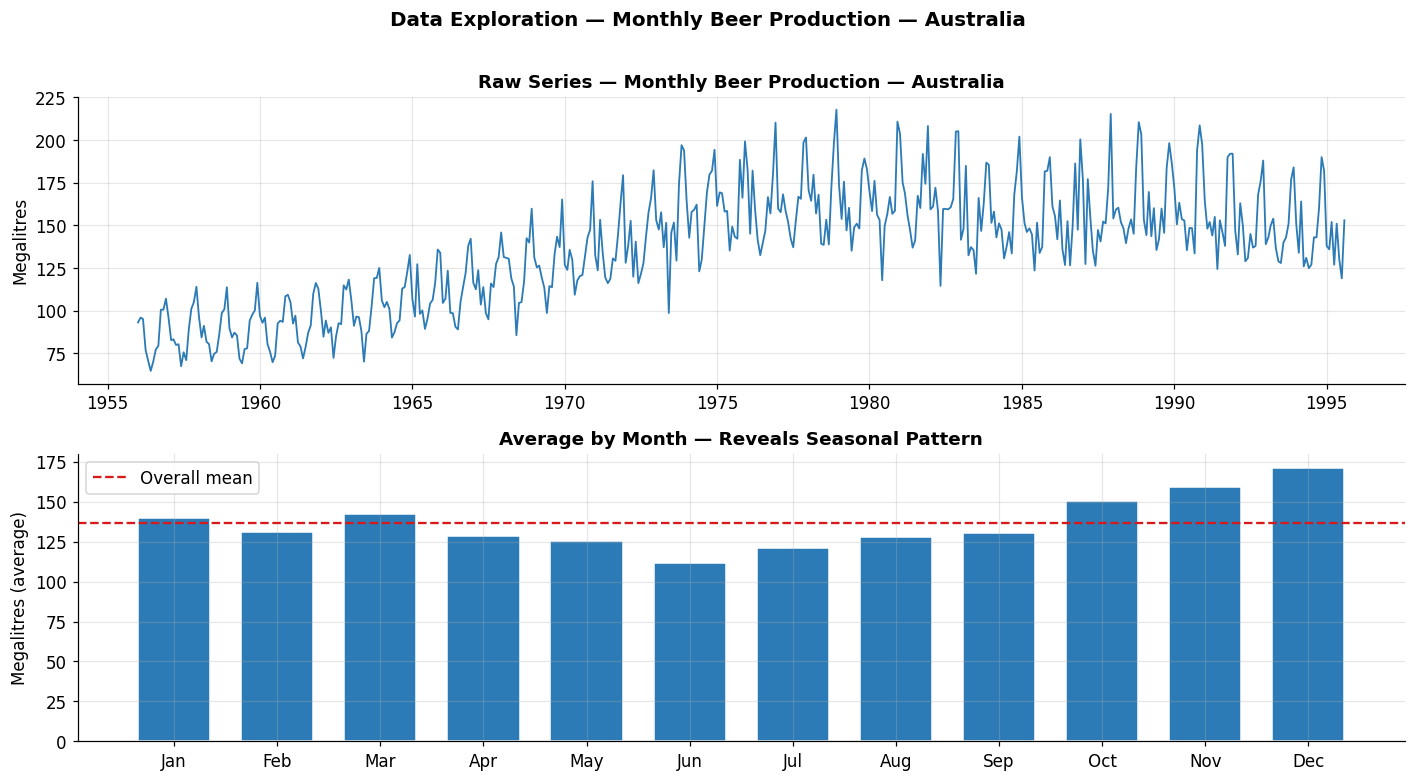

In [3]:
# ── Execute Step 1 ──
FILEPATH   = 'monthly-beer-production-in-austr.csv'
DATE_COL   = 'Month'
VALUE_COL  = 'Monthly beer production'

series_raw = load_data(FILEPATH, DATE_COL, VALUE_COL)
explore_data(series_raw, title='Monthly Beer Production — Australia')


## Step 2 — Train-Test Split

**Why split?**  
In time series, we cannot shuffle the data. We must preserve temporal order.
We use the last 24 months (2 years) as the test set and all prior data for training.
The model never sees test data during fitting — this gives an honest evaluation.


In [4]:
def train_test_split_ts(series, test_periods=24):
    """
    Split a time series into train and test sets (temporal order preserved).

    Parameters
    ----------
    series      : pd.Series — Full time series
    test_periods: int       — Number of periods to reserve for testing

    Returns
    -------
    train, test : pd.Series, pd.Series
    """
    train = series.iloc[:-test_periods]
    test  = series.iloc[-test_periods:]

    print("=" * 55)
    print("  TRAIN-TEST SPLIT")
    print("=" * 55)
    print(f"  Training   : {train.index.min().date()} → {train.index.max().date()} ({len(train)} obs)")
    print(f"  Test       : {test.index.min().date()} → {test.index.max().date()} ({len(test)} obs)")
    print(f"  Split ratio: {len(train)/len(series):.0%} train / {len(test)/len(series):.0%} test")
    print("=" * 55)

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(train, color=COLORS['blue'], linewidth=1.2, label=f'Train ({len(train)} obs)')
    ax.plot(test,  color=COLORS['red'],  linewidth=1.5, label=f'Test ({len(test)} obs)', linestyle='--')
    ax.axvline(test.index[0], color=COLORS['gray'], linewidth=1.2, linestyle=':')
    ax.set_title("Train-Test Split", fontweight='bold')
    ax.set_ylabel('Megalitres')
    ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()

    return train, test


  TRAIN-TEST SPLIT
  Training   : 1956-01-01 → 1993-08-01 (452 obs)
  Test       : 1993-09-01 → 1995-08-01 (24 obs)
  Split ratio: 95% train / 5% test


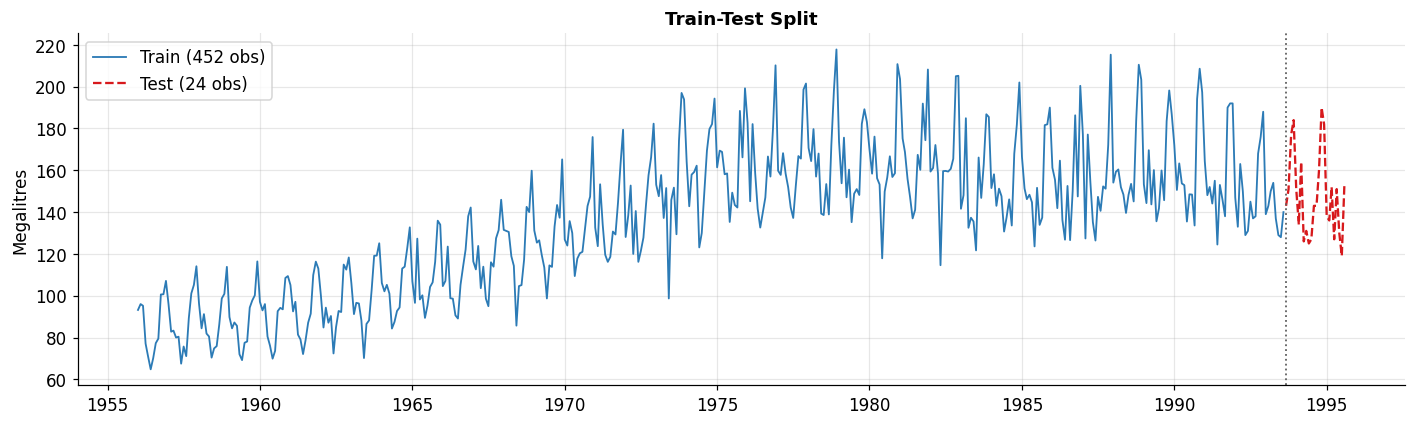

In [5]:
# ── Execute Step 2 ──
train, test = train_test_split_ts(series_raw, test_periods=24)


## Step 3 — Deseasonalisation (Multiplicative Decomposition)

**Why first?**  
The seasonal amplitude *grows* as the series level rises — this is the hallmark
of a **multiplicative** pattern. We remove seasonality *before* transforming so the
Box-Cox or Log can correctly stabilise variance on the deseasonalised series.

$$Y_t = T_t \times S_t \times R_t \implies \text{Deseasonalised}_t = Y_t / \hat{S}_t$$


In [6]:
def deseasonalise(train, period=12, model='multiplicative', plot=True):
    """
    Remove seasonality using classical decomposition.

    Parameters
    ----------
    train  : pd.Series — Training series
    period : int       — Seasonal period (12 for monthly)
    model  : str       — 'multiplicative' or 'additive'
    plot   : bool      — Whether to show decomposition plot

    Returns
    -------
    deseas_series  : pd.Series — Deseasonalised training series
    seasonal_comp  : pd.Series — Estimated seasonal factors (full, for inversion)
    decomp_result  : object    — Full decomposition result (for extracting seasonal later)
    """
    decomp = seasonal_decompose(train, model=model, period=period)

    if model == 'multiplicative':
        deseas = train / decomp.seasonal
    else:
        deseas = train - decomp.seasonal

    if plot:
        fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
        components = [train, decomp.trend, decomp.seasonal, decomp.resid]
        labels     = ['Observed', 'Trend', 'Seasonal', 'Residual']
        clrs       = [COLORS['blue'], COLORS['red'], COLORS['green'], COLORS['gray']]

        for ax, comp, label, clr in zip(axes, components, labels, clrs):
            ax.plot(comp, color=clr, linewidth=1.1)
            ax.set_ylabel(label, fontweight='bold')
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        axes[0].set_title(f"Classical {model.capitalize()} Decomposition (Training Data)",
                          fontweight='bold', fontsize=13)
        plt.tight_layout()
        plt.show()

        # Before vs After
        fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
        axes[0].plot(train,  color=COLORS['blue'],  linewidth=1.1, label='Original (with seasonality)')
        axes[1].plot(deseas, color=COLORS['green'], linewidth=1.1, label='Deseasonalised')
        axes[0].set_title("Before Deseasonalisation", fontweight='bold')
        axes[1].set_title("After Deseasonalisation", fontweight='bold')
        for ax in axes:
            ax.set_ylabel('Megalitres')
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.tight_layout()
        plt.show()

        print(f"✓ Deseasonalisation complete ({model} model, period={period})")

    return deseas, decomp.seasonal, decomp


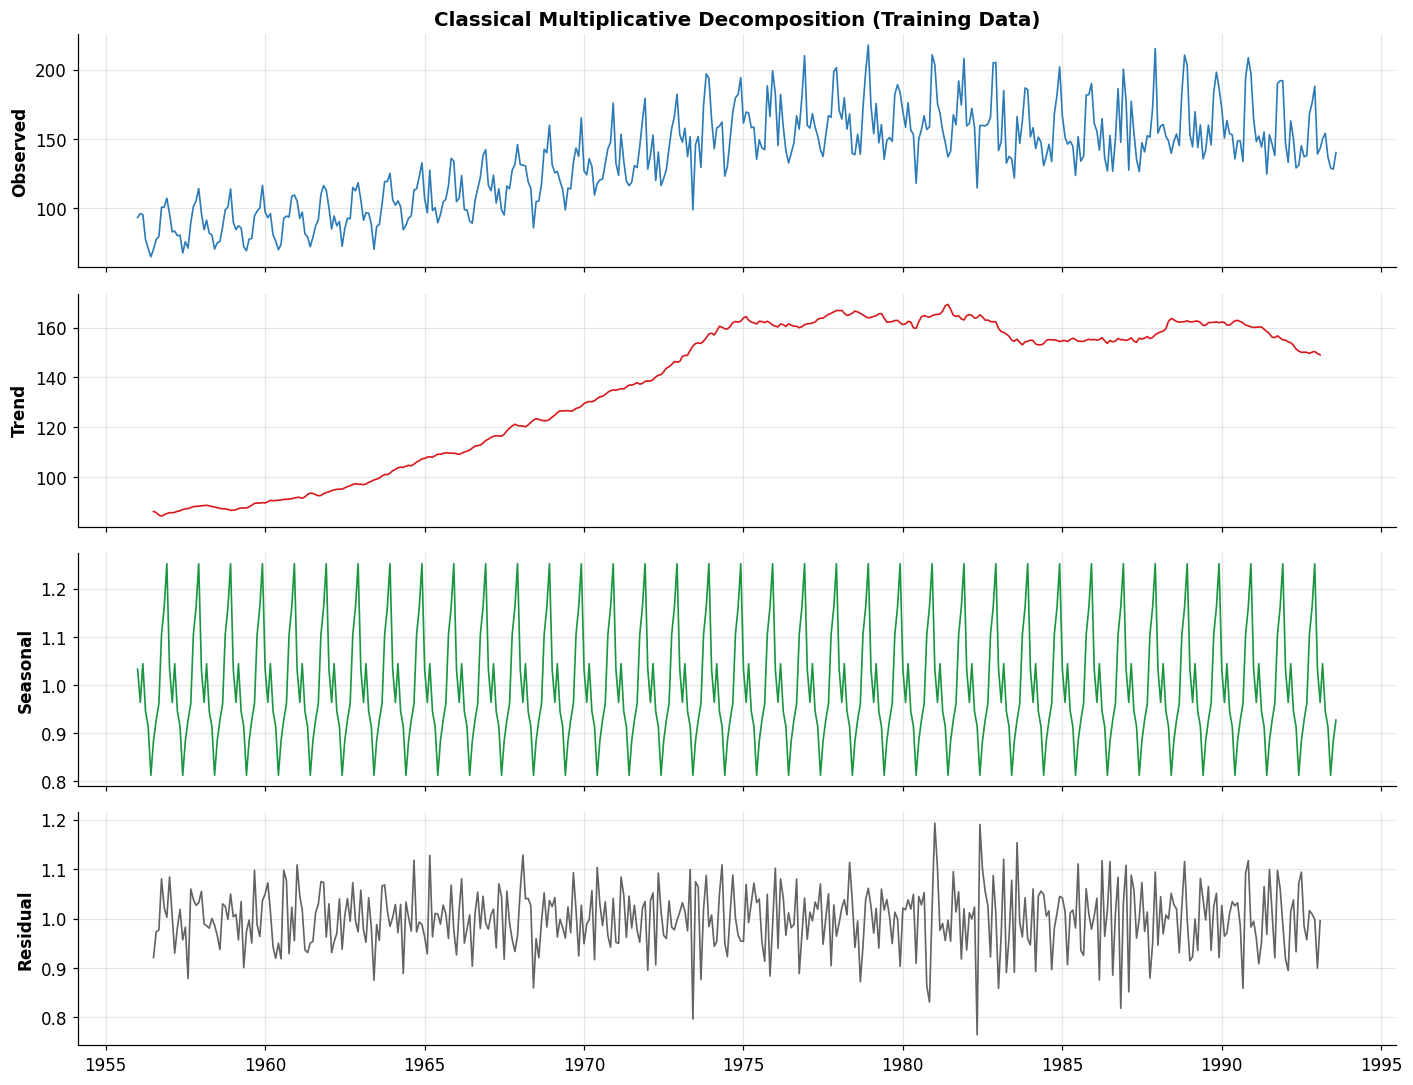

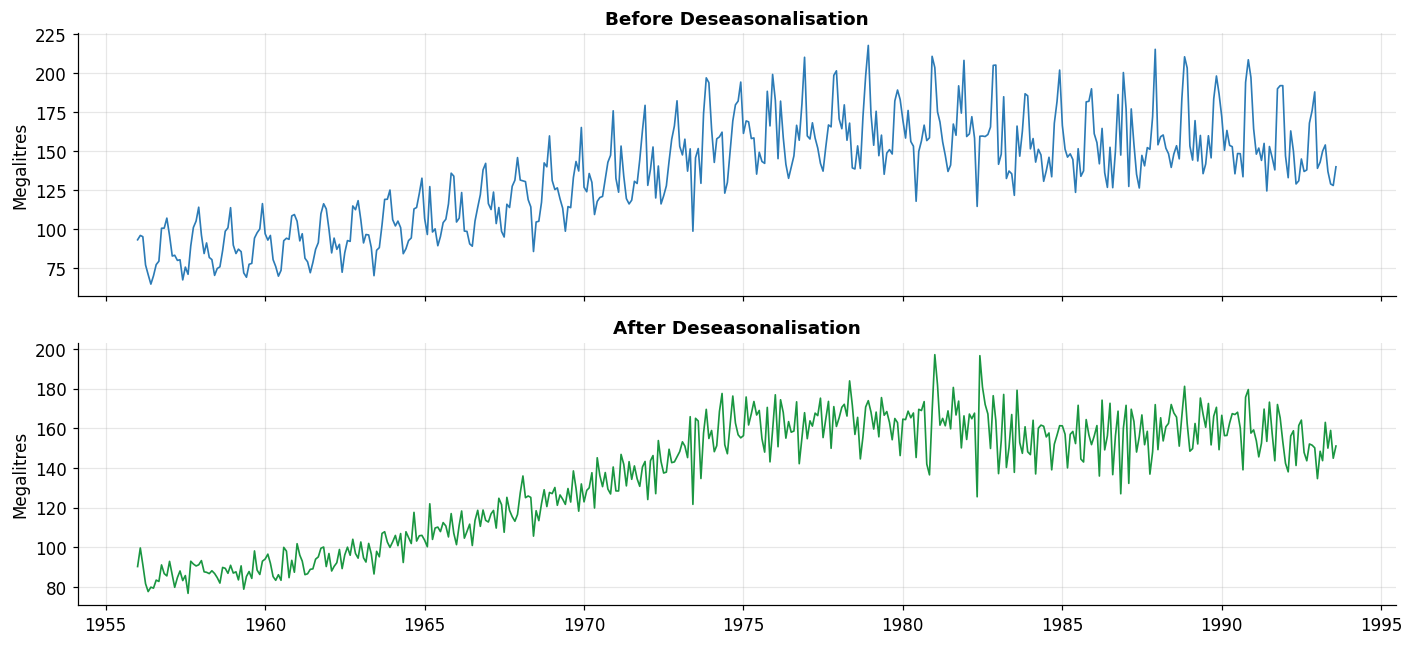

✓ Deseasonalisation complete (multiplicative model, period=12)


In [7]:
# ── Execute Step 3 ──
train_deseas, seasonal_comp, decomp_result = deseasonalise(train, period=12, model='multiplicative')


## Step 4 — Variance Stabilisation (Box-Cox Transformation)

**Why Box-Cox?**  
Box-Cox finds the optimal power transformation λ that makes the variance constant
across the range of values. It generalises the log transform (λ=0 gives log).

$$Y_t^{(\lambda)} = \begin{cases} \frac{Y_t^\lambda - 1}{\lambda} & \lambda \ne 0 \\ \ln(Y_t) & \lambda = 0 \end{cases}$$


In [8]:
def apply_boxcox(series, lmbda=None, plot=True):
    """
    Apply Box-Cox transformation to stabilise variance.

    Parameters
    ----------
    series : pd.Series — Series to transform (must be > 0)
    lmbda  : float     — If None, optimal lambda is estimated
    plot   : bool      — Show before/after plots

    Returns
    -------
    transformed : pd.Series — Box-Cox transformed series
    lmbda       : float     — Lambda used (needed for inverse)
    """
    clean = series.dropna()
    transformed_vals, lmbda_out = boxcox(clean.values, lmbda=lmbda)
    transformed = pd.Series(transformed_vals, index=clean.index)

    print("=" * 55)
    print("  BOX-COX TRANSFORMATION")
    print("=" * 55)
    print(f"  Optimal Lambda (λ) : {lmbda_out:.4f}")
    if abs(lmbda_out) < 0.1:
        interp = "≈ 0 → equivalent to log transformation"
    elif abs(lmbda_out - 0.5) < 0.1:
        interp = "≈ 0.5 → square-root transformation"
    elif abs(lmbda_out - 1.0) < 0.1:
        interp = "≈ 1 → no transformation needed"
    else:
        interp = "general power transformation"
    print(f"  Interpretation     : λ {interp}")
    print("=" * 55)

    if plot:
        fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
        axes[0].plot(clean,       color=COLORS['red'],   linewidth=1.1)
        axes[0].set_title("Before Box-Cox (Deseasonalised)", fontweight='bold')
        axes[0].set_ylabel('Level')
        axes[1].plot(transformed, color=COLORS['green'], linewidth=1.1)
        axes[1].set_title(f"After Box-Cox (λ = {lmbda_out:.3f})", fontweight='bold')
        axes[1].set_ylabel('Transformed')
        for ax in axes:
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.tight_layout()
        plt.show()

    return transformed, lmbda_out


def inverse_boxcox(transformed, lmbda):
    """Invert a Box-Cox transformation back to original scale."""
    return inv_boxcox(transformed, lmbda)


**Why Log Transform?**  
The log transformation reduces the spread of large observations and helps
stabilise variance when fluctuations grow with the level of the series.

$$
Y_t^{*} = \ln(Y_t)
$$

In [9]:
def apply_log(series, plot=True):
    """
    Apply natural log transformation to stabilise variance.
    Series must be strictly positive.

    Parameters
    ----------
    series : pd.Series — Series to transform (must be > 0)
    plot   : bool      — Show before/after plots

    Returns
    -------
    transformed : pd.Series — Log-transformed series
    """
    clean = series.dropna()
    transformed = np.log(clean)

    print("=" * 55)
    print("  LOG TRANSFORMATION")
    print("=" * 55)
    print(f"  Min before : {clean.min():.4f}  (must be > 0)")
    print(f"  Mean before: {clean.mean():.4f}")
    print(f"  Std before : {clean.std():.4f}")
    print(f"  Std after  : {transformed.std():.4f}")
    print("=" * 55)

    if plot:
        fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
        axes[0].plot(clean,       color=COLORS['red'],   linewidth=1.1)
        axes[0].set_title("Before Log Transform (Deseasonalised)", fontweight='bold')
        axes[0].set_ylabel('Level')
        axes[1].plot(transformed, color=COLORS['green'], linewidth=1.1)
        axes[1].set_title("After Log Transform", fontweight='bold')
        axes[1].set_ylabel('Log Level')
        for ax in axes:
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.tight_layout()
        plt.show()

    return transformed


def inverse_log(transformed):
    """Invert log transformation back to original scale."""
    return np.exp(transformed)

  LOG TRANSFORMATION
  Min before : 76.7166  (must be > 0)
  Mean before: 135.9727
  Std before : 30.2736
  Std after  : 0.2416


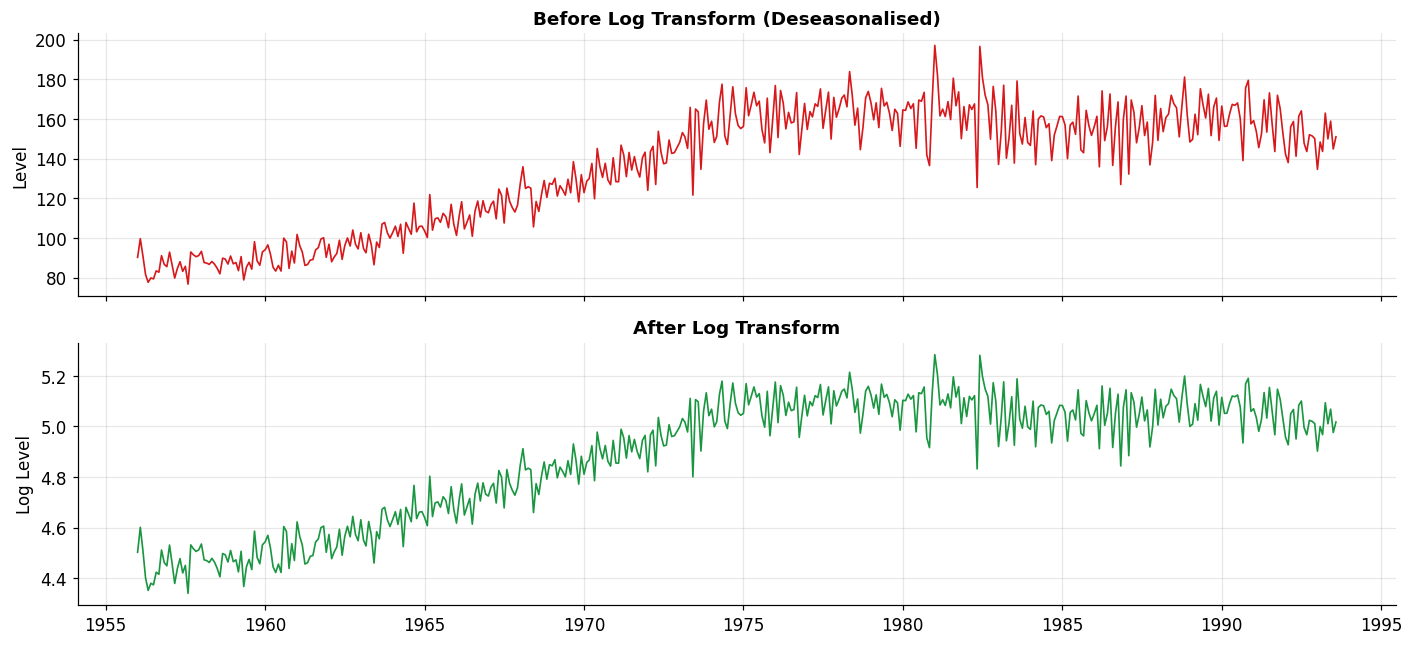

In [10]:
# ── Execute Step 4 ──
train_bc = apply_log(train_deseas)


## Step 5 — Differencing for Stationarity

ARIMA models require **stationarity** (constant mean and variance over time).
After deseasonalisation and Log transformation, the series still has a trend.
First-order differencing removes it:

$$\Delta Y_t = Y_t - Y_{t-1}$$


In [11]:
def difference_series(series, order=1, plot=True):
    """
    Apply d-th order differencing to a time series.

    Parameters
    ----------
    series : pd.Series — Series to difference
    order  : int       — Differencing order (1 = first difference)
    plot   : bool      — Show original vs differenced plot

    Returns
    -------
    differenced : pd.Series — Differenced series (with NaN at start dropped)
    """
    differenced = series.copy()
    for _ in range(order):
        differenced = differenced.diff()
    differenced = differenced.dropna()

    if plot:
        fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
        axes[0].plot(series,      color=COLORS['blue'],   linewidth=1.1)
        axes[0].set_title(f"Before Differencing (Log scale)", fontweight='bold')
        axes[0].set_ylabel('Level')
        axes[1].plot(differenced, color=COLORS['purple'], linewidth=1.1)
        axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axes[1].set_title(f"After {order}-st Order Differencing (Stationary)", fontweight='bold')
        axes[1].set_ylabel(f"Δ Level")
        for ax in axes:
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.tight_layout()
        plt.show()
        print(f"✓ Applied order-{order} differencing  |  {len(series)} → {len(differenced)} obs")

    return differenced


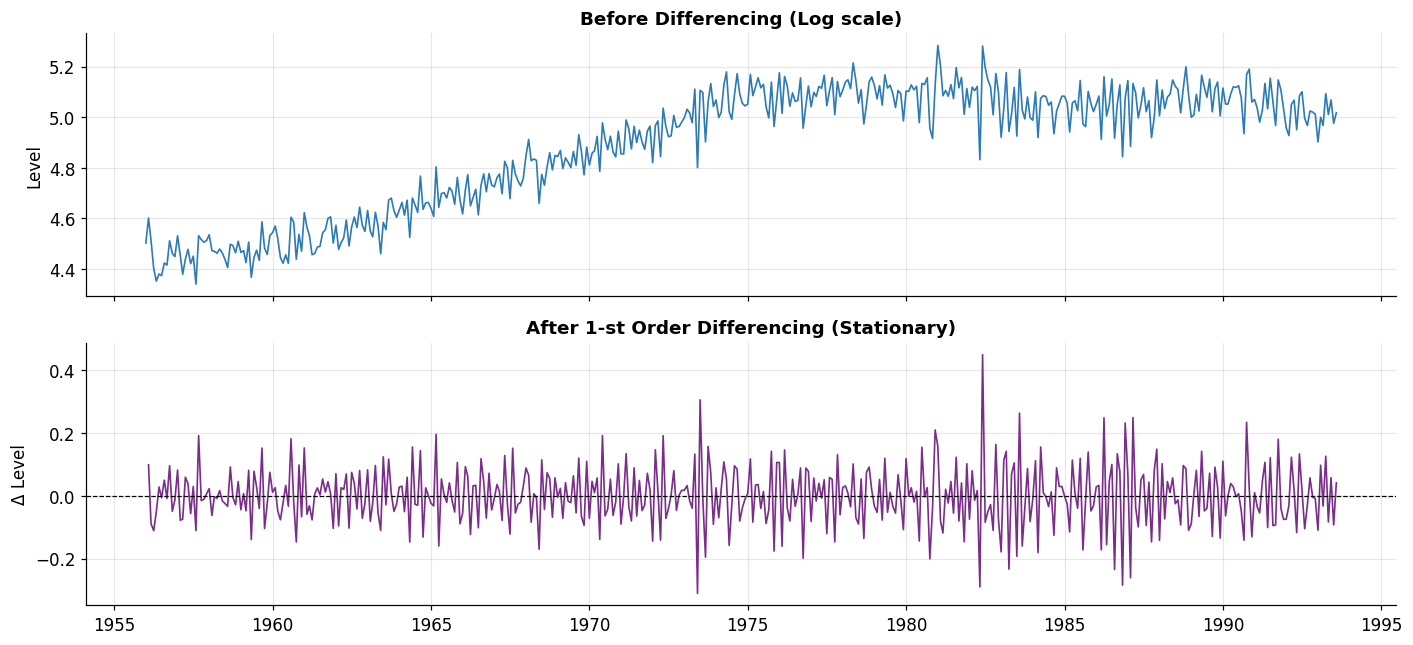

✓ Applied order-1 differencing  |  452 → 451 obs


In [12]:
# ── Execute Step 6 ──
train_diff = difference_series(train_bc, order=1)


## Step 6 — Stationarity Tests (ADF Test)

The **Augmented Dickey-Fuller (ADF)** test formally checks for a unit root.

- **H₀:** Series has a unit root → non-stationary  
- **H₁:** Series is stationary  
- **p-value < 0.05** → reject H₀ → stationary ✓

We test both the Box-Cox series (should fail) and the differenced series (should pass).


In [13]:
def adf_test(series, label="Series"):
    """
    Augmented Dickey-Fuller test for stationarity.

    Parameters
    ----------
    series : pd.Series — Series to test
    label  : str       — Label for display

    Returns
    -------
    p_val : float — p-value of the test
    """
    result = adfuller(series.dropna(), autolag='AIC')
    adf_stat, p_val, n_lags, _, crit_vals, _ = result

    print("=" * 55)
    print(f"  ADF TEST — {label}")
    print("=" * 55)
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_val:.6f}")
    print(f"  Lags used     : {n_lags}")
    print("  Critical Values:")
    for key, val in crit_vals.items():
        marker = " ← more extreme" if adf_stat < val else ""
        print(f"     {key:5s} : {val:.4f}{marker}")
    print("-" * 55)
    if p_val < 0.05:
        print("  ✓  Reject H₀ → Series is STATIONARY")
    else:
        print("  ✗  Fail to reject H₀ → Series is NON-STATIONARY")
    print("=" * 55)

    return p_val


In [14]:
# ── Execute Step 7 ──
print("Testing the Box-Cox series (before differencing):")
adf_test(train_bc, label="Box-Cox (before diff)")

print("\nTesting the differenced series (our modelling input):")
adf_pval = adf_test(train_diff, label="Box-Cox + First Difference")


Testing the Box-Cox series (before differencing):
  ADF TEST — Box-Cox (before diff)
  ADF Statistic : -2.7890
  p-value       : 0.059866
  Lags used     : 15
  Critical Values:
     1%    : -3.4454
     5%    : -2.8682
     10%   : -2.5703 ← more extreme
-------------------------------------------------------
  ✗  Fail to reject H₀ → Series is NON-STATIONARY

Testing the differenced series (our modelling input):
  ADF TEST — Box-Cox + First Difference
  ADF Statistic : -4.4528
  p-value       : 0.000239
  Lags used     : 18
  Critical Values:
     1%    : -3.4456 ← more extreme
     5%    : -2.8683 ← more extreme
     10%   : -2.5703 ← more extreme
-------------------------------------------------------
  ✓  Reject H₀ → Series is STATIONARY


## Step 7 — ACF & PACF Analysis

**Autocorrelation Function (ACF):** Shows how correlated the series is with its own lags.
Spikes beyond the confidence band at lag *q* suggest an **MA(q)** component.

**Partial ACF (PACF):** Removes the effect of intermediate lags.
Spikes beyond the confidence band at lag *p* suggest an **AR(p)** component.

> These are guidelines, not rules — we compare multiple models formally.


In [15]:
def plot_acf_pacf(series, lags=30, title="Stationary Series"):
    """
    Plot ACF and PACF side by side.

    Parameters
    ----------
    series : pd.Series — Stationary series
    lags   : int       — Number of lags to display
    title  : str       — Subplot title
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(series.dropna(), lags=lags, ax=axes[0], color=COLORS['blue'])
    axes[0].set_title(f"ACF — {title}\n(spikes → MA order q)", fontweight='bold')
    axes[0].set_xlabel("Lag")
    axes[0].set_ylabel("Autocorrelation")

    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method='yw', color=COLORS['red'])
    axes[1].set_title(f"PACF — {title}\n(spikes → AR order p)", fontweight='bold')
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("Partial Autocorrelation")

    plt.tight_layout()
    plt.show()


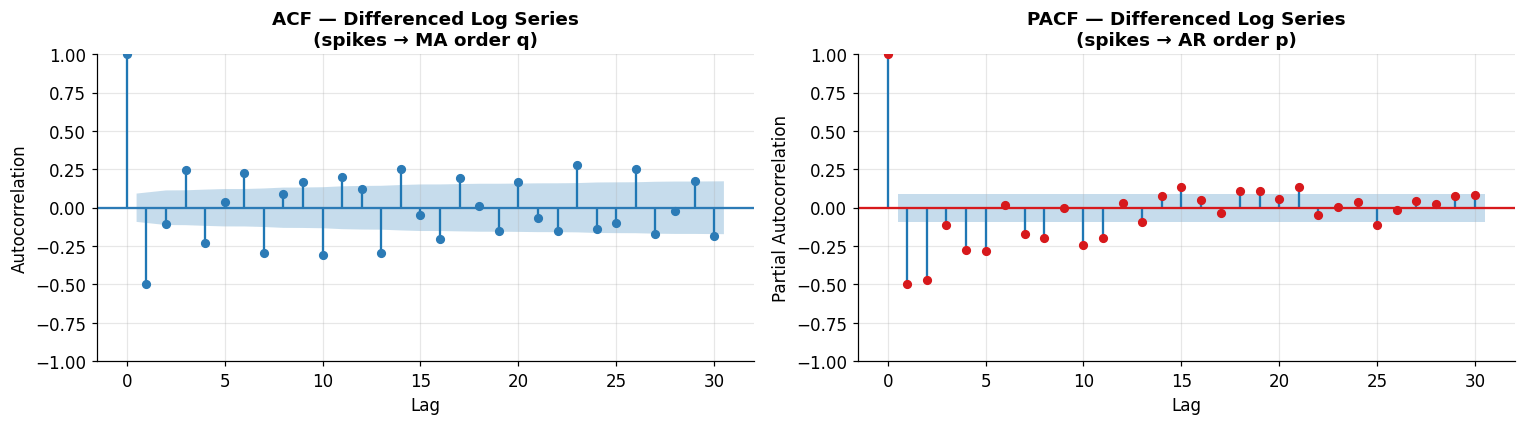

In [16]:
# ── Execute Step 8 ──
plot_acf_pacf(train_diff, lags=30, title="Differenced Log Series")


## Step 8 — Fit Multiple ARIMA Models

We fit several candidate ARIMA(p, d, q) models on the **training data** and
record key statistics for each. We use d=1 since we already differenced,
but ARIMA handles this internally.

**Selection criteria:**
- **AIC / BIC** — lower is better; BIC penalises complexity more
- **Ljung-Box p-value** — should be > 0.05 (white-noise residuals)
- **Coefficient significance** — all params should be significant (p < 0.05)
- **Parsimony** — simplest model that satisfies all criteria wins


In [17]:
def fit_arima(series, p, d, q, label=None):
    """
    Fit an ARIMA(p, d, q) model.

    Parameters
    ----------
    series : pd.Series — Stationary training series (on Box-Cox scale)
    p, d, q: int       — ARIMA orders
    label  : str       — Optional display label

    Returns
    -------
    model_fit : fitted ARIMA model
    metrics   : dict of key metrics
    """
    if label is None:
        label = f"ARIMA({p},{d},{q})"

    model     = sm.tsa.ARIMA(series, order=(p, d, q))
    model_fit = model.fit()

    # Ljung-Box at lag 10 (standard for monthly)
    lb         = acorr_ljungbox(model_fit.resid, lags=[10], return_df=True)
    lb_pval    = float(lb['lb_pvalue'].iloc[0])

    # Check coefficient significance
    pvals      = model_fit.pvalues.drop('sigma2', errors='ignore')
    all_sig    = all(pvals < 0.05)
    insig      = pvals[pvals >= 0.05].index.tolist()

    metrics = {
        'Label'      : label,
        'AIC'        : round(model_fit.aic, 2),
        'BIC'        : round(model_fit.bic, 2),
        'LogLik'     : round(model_fit.llf, 2),
        'LjungBox_p' : round(lb_pval, 4),
        'AllSig'     : all_sig,
        'InsigParams': ', '.join(insig) if insig else '—',
    }

    return model_fit, metrics


In [18]:
def compare_models(series, candidates):
    """
    Fit and compare multiple ARIMA models.

    Parameters
    ----------
    series     : pd.Series       — Training series (will be differenced internally via d)
    candidates : list of (p,d,q) — List of ARIMA orders to try

    Returns
    -------
    fitted_models  : dict  — {label: fitted model}
    comparison_df  : DataFrame — Comparison table
    """
    fitted_models = {}
    rows = []

    for (p, d, q) in candidates:
        label = f"ARIMA({p},{d},{q})"
        try:
            model_fit, metrics = fit_arima(series, p, d, q, label)
            fitted_models[label] = model_fit
            rows.append(metrics)
            print(f"  ✓ Fitted {label}  |  AIC={metrics['AIC']:.1f}  LB_p={metrics['LjungBox_p']:.3f}  AllSig={metrics['AllSig']}")
        except Exception as e:
            print(f"  ✗ Failed {label}: {e}")

    comparison_df = pd.DataFrame(rows).sort_values('AIC')
    return fitted_models, comparison_df


In [19]:
# ── Execute Step 9 ──
# Candidate models: varying AR and MA orders, d=1 for stationarity
CANDIDATES = [
    (1, 1, 0),   # AR(1)
    (0, 1, 1),   # MA(1)
    (1, 1, 1),   # ARIMA(1,1,1)
    (2, 1, 1),   # ARIMA(2,1,1)
    (2, 1, 2),   # ARIMA(2,1,2)
    (3, 1, 1),   # ARIMA(3,1,1)
    (2, 1, 3),   # ARIMA(2,1,3)
]

print("Fitting ARIMA candidates on training data...")
print("=" * 60)
fitted_models, comparison_df = compare_models(train_bc, CANDIDATES)
print("\n✓ All models fitted.")


Fitting ARIMA candidates on training data...
  ✓ Fitted ARIMA(1,1,0)  |  AIC=-961.2  LB_p=0.925  AllSig=True
  ✓ Fitted ARIMA(0,1,1)  |  AIC=-1120.6  LB_p=0.994  AllSig=True
  ✓ Fitted ARIMA(1,1,1)  |  AIC=-1123.5  LB_p=0.990  AllSig=True
  ✓ Fitted ARIMA(2,1,1)  |  AIC=-1130.6  LB_p=0.985  AllSig=True
  ✓ Fitted ARIMA(2,1,2)  |  AIC=-1136.1  LB_p=0.989  AllSig=False
  ✓ Fitted ARIMA(3,1,1)  |  AIC=-1131.8  LB_p=0.988  AllSig=False
  ✓ Fitted ARIMA(2,1,3)  |  AIC=-1201.3  LB_p=0.996  AllSig=False

✓ All models fitted.


In [20]:
# ── Model Comparison Table ──
print("\n" + "=" * 70)
print("  ARIMA MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)
print("\n  Selection criteria:")
print("  • AIC/BIC    → lower is better")
print("  • LjungBox_p → must be > 0.05 (white-noise residuals)")
print("  • AllSig     → all parameters must be significant (p < 0.05)")



  ARIMA MODEL COMPARISON TABLE
       Label      AIC      BIC  LogLik  LjungBox_p  AllSig  InsigParams
ARIMA(2,1,3) -1201.28 -1176.61  606.64      0.9960   False        ma.L2
ARIMA(2,1,2) -1136.12 -1115.56  573.06      0.9894   False        ma.L1
ARIMA(3,1,1) -1131.84 -1111.28  570.92      0.9882   False ar.L1, ar.L3
ARIMA(2,1,1) -1130.58 -1114.13  569.29      0.9851    True            —
ARIMA(1,1,1) -1123.45 -1111.12  564.73      0.9901    True            —
ARIMA(0,1,1) -1120.62 -1112.40  562.31      0.9939    True            —
ARIMA(1,1,0)  -961.16  -952.93  482.58      0.9253    True            —

  Selection criteria:
  • AIC/BIC    → lower is better
  • LjungBox_p → must be > 0.05 (white-noise residuals)
  • AllSig     → all parameters must be significant (p < 0.05)


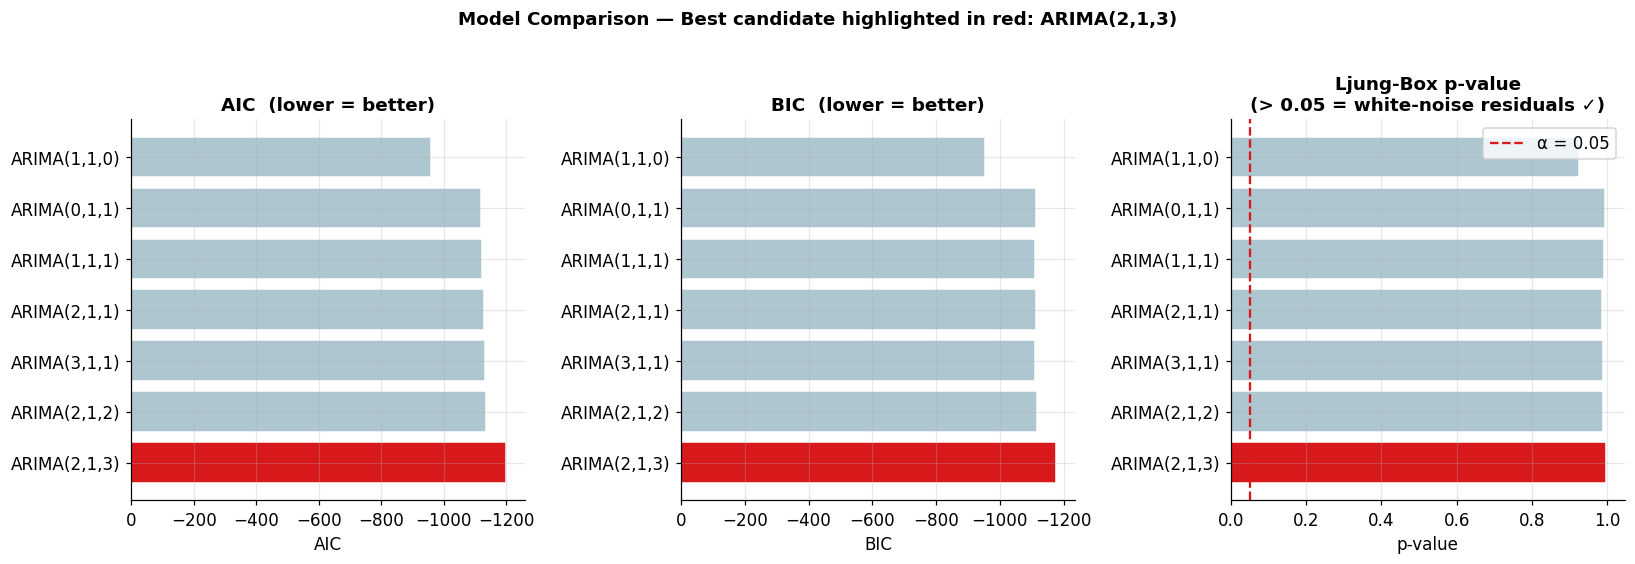

In [21]:
# ── Visual Comparison ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels_list = comparison_df['Label'].tolist()

# Use color: best model = highlighted
best_label = comparison_df.iloc[0]['Label']
colors_bar = [COLORS['red'] if l == best_label else '#aec6cf' for l in labels_list]

# AIC
axes[0].barh(labels_list, comparison_df['AIC'], color=colors_bar, edgecolor='white')
axes[0].set_title("AIC  (lower = better)", fontweight='bold')
axes[0].set_xlabel("AIC")
axes[0].invert_xaxis()

# BIC
axes[1].barh(labels_list, comparison_df['BIC'], color=colors_bar, edgecolor='white')
axes[1].set_title("BIC  (lower = better)", fontweight='bold')
axes[1].set_xlabel("BIC")
axes[1].invert_xaxis()

# Ljung-Box p-value
axes[2].barh(labels_list, comparison_df['LjungBox_p'], color=colors_bar, edgecolor='white')
axes[2].axvline(0.05, color=COLORS['red'], linestyle='--', linewidth=1.5, label='α = 0.05')
axes[2].set_title("Ljung-Box p-value\n(> 0.05 = white-noise residuals ✓)", fontweight='bold')
axes[2].set_xlabel("p-value")
axes[2].legend()

plt.suptitle(f"Model Comparison — Best candidate highlighted in red: {best_label}",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Step 9 — Residual Diagnostics

A well-fitted ARIMA model should leave behind **white-noise residuals**:
1. No remaining autocorrelation (ACF of residuals all within bands)
2. Approximately normally distributed (histogram + QQ plot)
3. No systematic pattern over time (residual plot flat around zero)
4. Ljung-Box p-value > 0.05 at multiple lags


In [22]:
def residual_diagnostics(model_fit, label="Model"):
    """
    Complete residual diagnostics for a fitted ARIMA model.

    Parameters
    ----------
    model_fit : fitted statsmodels ARIMA
    label     : str — Display label
    """
    residuals = model_fit.resid.dropna()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # 1. Residuals over time
    axes[0, 0].plot(residuals, color=COLORS['purple'], linewidth=0.9)
    axes[0, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0, 0].set_title("Residuals Over Time\n(should scatter around zero)")
    axes[0, 0].set_ylabel("Residual")

    # 2. ACF of residuals
    plot_acf(residuals, lags=24, ax=axes[0, 1], color=COLORS['blue'])
    axes[0, 1].set_title("ACF of Residuals\n(all spikes should be inside band)")

    # 3. Histogram + KDE + Normal overlay
    axes[0, 2].hist(residuals, bins=25, color=COLORS['blue'], edgecolor='white',
                    density=True, alpha=0.7, label='Histogram')
    xrng = np.linspace(residuals.min(), residuals.max(), 200)
    axes[0, 2].plot(xrng, stats.norm.pdf(xrng, residuals.mean(), residuals.std()),
                    color=COLORS['red'], linewidth=2, label='Normal fit')
    # KDE
    kde = stats.gaussian_kde(residuals)
    axes[0, 2].plot(xrng, kde(xrng), color=COLORS['green'], linewidth=1.5,
                    linestyle='--', label='KDE')
    axes[0, 2].set_title("Residual Distribution\n(should be approximately normal)")
    axes[0, 2].legend(fontsize=8)

    # 4. Q-Q Plot
    sm.qqplot(residuals, line='s', ax=axes[1, 0], alpha=0.5, markersize=3)
    axes[1, 0].set_title("Q-Q Plot\n(points on line = normal residuals)")

    # 5. Residuals vs Fitted values
    fitted_vals = model_fit.fittedvalues
    axes[1, 1].scatter(fitted_vals, residuals, alpha=0.4, s=12, color=COLORS['purple'])
    axes[1, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1, 1].set_xlabel("Fitted Values")
    axes[1, 1].set_ylabel("Residuals")
    axes[1, 1].set_title("Residuals vs Fitted\n(no pattern = good)")

    # 6. Ljung-Box p-values across lags
    lb_lags = [5, 10, 15, 20, 25]
    lb_res = acorr_ljungbox(residuals, lags=lb_lags, return_df=True)
    axes[1, 2].plot(lb_lags, lb_res['lb_pvalue'].values, 'o-',
                    color=COLORS['blue'], linewidth=1.5, markersize=6)
    axes[1, 2].axhline(0.05, color=COLORS['red'], linestyle='--', linewidth=1.5, label='α = 0.05')
    axes[1, 2].set_ylim(0, 1)
    axes[1, 2].set_title("Ljung-Box p-values by Lag\n(all must be above 0.05)")
    axes[1, 2].set_xlabel("Lag")
    axes[1, 2].set_ylabel("p-value")
    axes[1, 2].legend()

    plt.suptitle(f"Residual Diagnostics — {label}",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Print Ljung-Box results
    print("\nLjung-Box Test Results:")
    print(lb_res.to_string())
    all_good = all(lb_res['lb_pvalue'] > 0.05)
    if all_good:
        print("\n  ✓ All p-values > 0.05 → Residuals are white noise ✓")
    else:
        print("\n  ✗ Some p-values ≤ 0.05 → Residual autocorrelation remains")

    # Normality test
    _, norm_pval = stats.shapiro(residuals[:50])  # Shapiro on first 50 (sensitive to n)
    print(f"\nShapiro-Wilk normality test (first 50 residuals): p = {norm_pval:.4f}")
    if norm_pval > 0.05:
        print("  ✓ Residuals appear approximately normal")
    else:
        print("  ✗ Residuals deviate from normality (check QQ plot)")

    return lb_res


In [23]:
# ── Select best model and run diagnostics ──
# Best model = lowest AIC with LB p > 0.05 and all coefs significant
valid_models = comparison_df[
    (comparison_df['LjungBox_p'] > 0.05) &
    (comparison_df['AllSig'] == True)
]

if len(valid_models) > 0:
    best_label = valid_models.iloc[0]['Label']   # already sorted by AIC
else:
    best_label = comparison_df.iloc[0]['Label']  # fallback: lowest AIC

print(f"✓ Selected model: {best_label}")
print(f"  AIC         : {comparison_df[comparison_df['Label']==best_label]['AIC'].values[0]}")
print(f"  BIC         : {comparison_df[comparison_df['Label']==best_label]['BIC'].values[0]}")
print(f"  LjungBox_p  : {comparison_df[comparison_df['Label']==best_label]['LjungBox_p'].values[0]}")

best_model = fitted_models[best_label]
print("\n--- Full Model Summary ---")
print(best_model.summary())


✓ Selected model: ARIMA(2,1,1)
  AIC         : -1130.58
  BIC         : -1114.13
  LjungBox_p  : 0.9851

--- Full Model Summary ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  452
Model:                 ARIMA(2, 1, 1)   Log Likelihood                 569.288
Date:                Thu, 25 Jun 2026   AIC                          -1130.576
Time:                        18:28:29   BIC                          -1114.130
Sample:                    01-01-1956   HQIC                         -1124.095
                         - 08-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1611      0.049     -3.286      0.001      -0.257      -0.065

## Step 10 — Variance Diagnostics (Breusch-Pagan Test)

**Goal:** Confirm that the variance of residuals are successfully stabilized.  
- **H₀:** Variance is constant (homoscedastic) — what we want  
- **H₁:** Variance changes systematically (heteroscedastic)  
- **p-value > 0.05** → fail to reject H₀ → variance is stable ✓


In [24]:
def rolling_variance_plot(before, after, labels=('Before', 'After'), window=24):
    """
    Plot rolling mean vs rolling std to visually assess variance stability.

    Parameters
    ----------
    before, after : pd.Series — Series before and after transformation
    labels        : tuple     — Labels for the two series
    window        : int       — Rolling window size
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, s, label, color in zip(axes, [before, after], labels, [COLORS['red'], COLORS['green']]):
        s_clean = s.dropna()
        roll_mean = s_clean.rolling(window).mean()
        roll_std  = s_clean.rolling(window).std()
        ax.plot(roll_mean, color=color, linewidth=1.4, label='Rolling Mean')
        ax.fill_between(s_clean.index,
                        roll_mean - roll_std,
                        roll_mean + roll_std,
                        alpha=0.25, color=color, label='±1 Std')
        ax.set_title(f"{label} — Rolling Mean ± Std (window={window})", fontweight='bold')
        ax.set_ylabel('Level')
        ax.legend(fontsize=9)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.suptitle("Rolling Variance: Stable bands = homoscedastic ✓", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def breusch_pagan_test(series, label="Series"):
    """
    Breusch-Pagan test for heteroscedasticity.

    Parameters
    ----------
    series : pd.Series — Series to test
    label  : str       — Label for display

    Returns
    -------
    lm_pval : float — p-value of LM test
    """
    clean = series.dropna()
    X = sm.add_constant(np.arange(len(clean)))
    ols = sm.OLS(clean.values, X).fit()
    lm_stat, lm_pval, f_stat, f_pval = het_breuschpagan(ols.resid, ols.model.exog)

    print("=" * 55)
    print(f"  BREUSCH-PAGAN TEST — {label}")
    print("=" * 55)
    print(f"  LM Statistic (Chi-Sq) : {lm_stat:.4f}")
    print(f"  LM p-value            : {lm_pval:.4f}")
    print(f"  F-Statistic           : {f_stat:.4f}")
    print(f"  F-Test p-value        : {f_pval:.4f}")
    print("-" * 55)
    if lm_pval > 0.05:
        print("  ✓  Fail to reject H₀ → HOMOSCEDASTIC (variance stable)")
    else:
        print("  ✗  Reject H₀ → HETEROSCEDASTIC (variance not stable)")
    print("=" * 55)

    return lm_pval


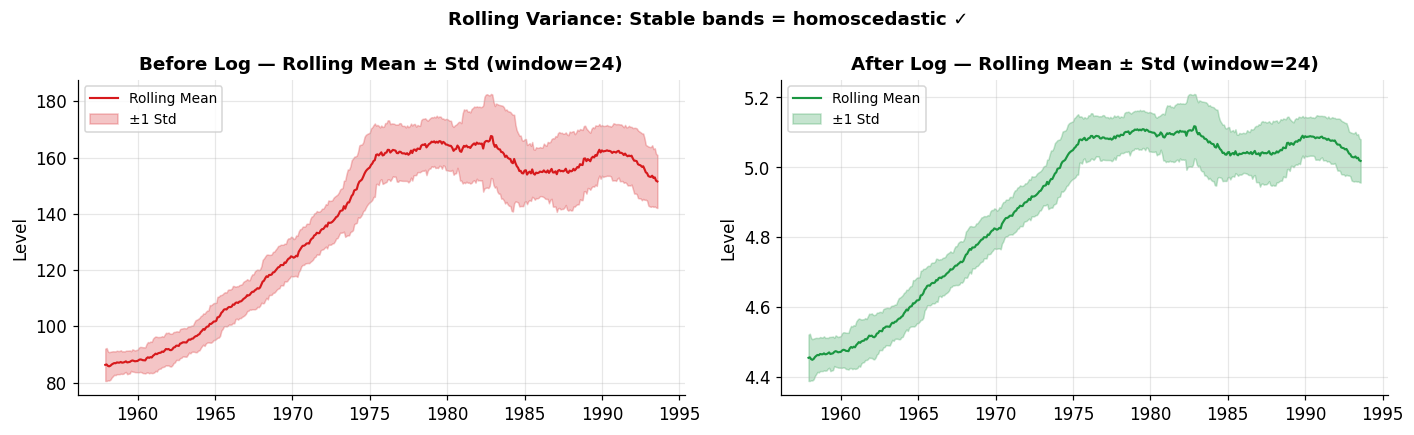

  BREUSCH-PAGAN TEST — ARIMA Residuals — ARIMA(2,1,1)
  LM Statistic (Chi-Sq) : 2.9911
  LM p-value            : 0.0837
  F-Statistic           : 2.9977
  F-Test p-value        : 0.0841
-------------------------------------------------------
  ✓  Fail to reject H₀ → HOMOSCEDASTIC (variance stable)


In [25]:
# ── Breusch-Pagan on ARIMA Model Residuals ──
# This is the correct place: test whether the model residuals are homoscedastic.
# H0: residual variance is constant (homoscedastic) — what we want.
# ── Execute Step 5 ──
rolling_variance_plot(train_deseas, train_bc,
                      labels=('Before Log', 'After Log'))

residuals = best_model.resid.dropna()
bp_pval = breusch_pagan_test(residuals, label=f"ARIMA Residuals — {best_label}")

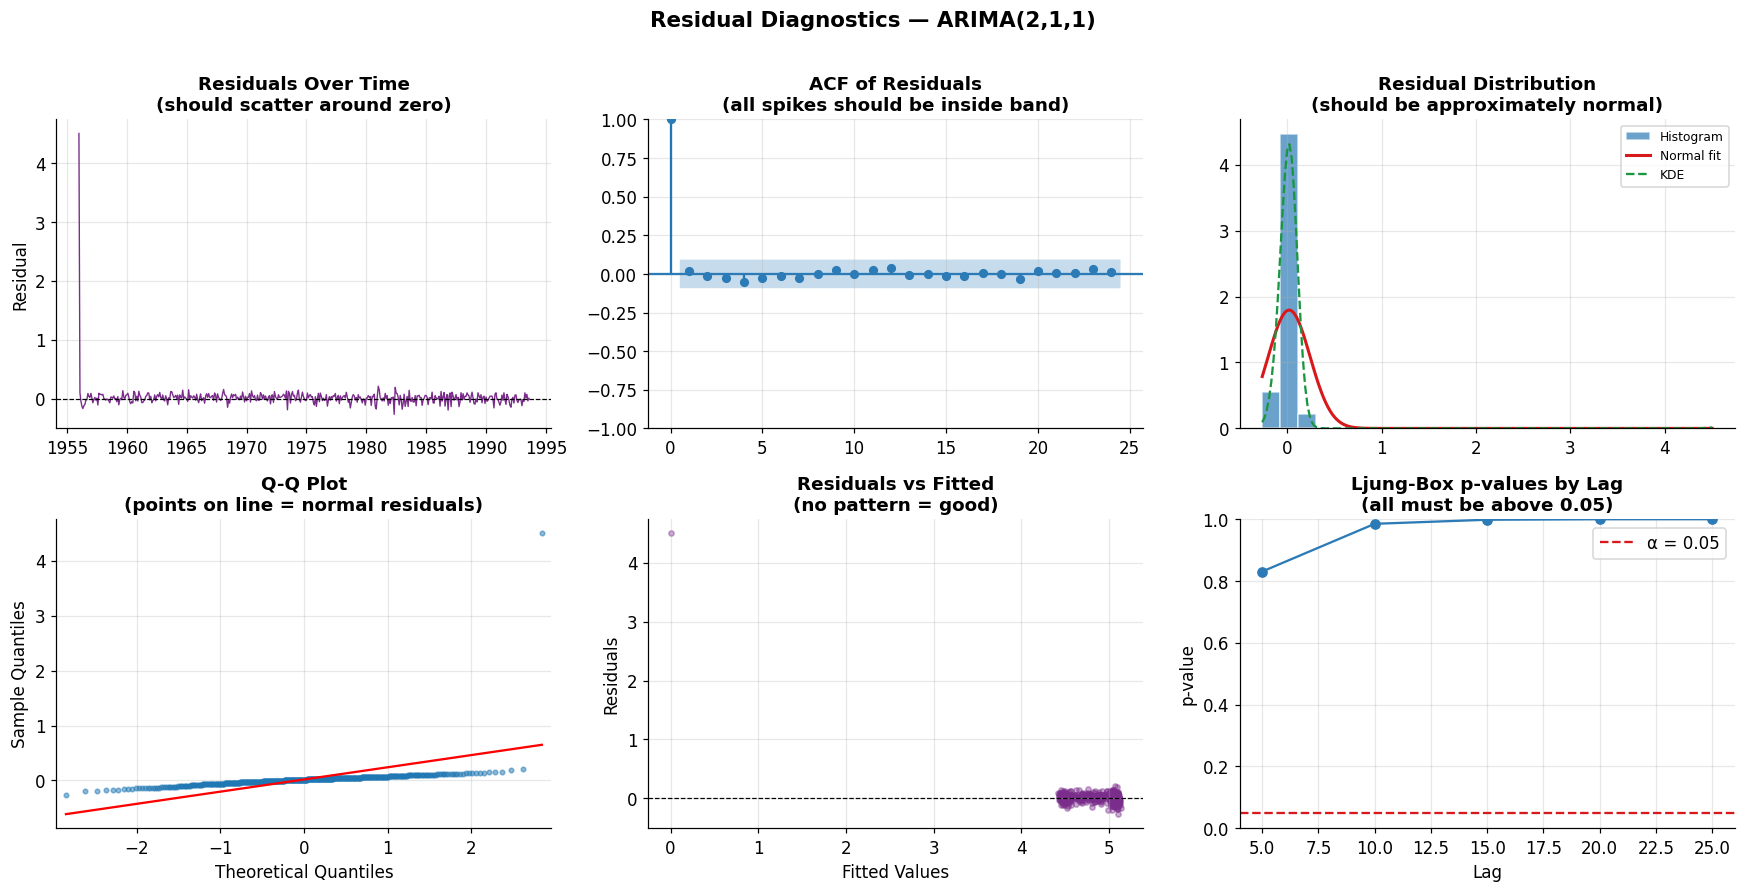


Ljung-Box Test Results:
     lb_stat  lb_pvalue
5   2.130904   0.830752
10  2.830942   0.985127
15  3.797719   0.998328
20  4.600005   0.999856
25  5.202139   0.999992

  ✓ All p-values > 0.05 → Residuals are white noise ✓

Shapiro-Wilk normality test (first 50 residuals): p = 0.0000
  ✗ Residuals deviate from normality (check QQ plot)


In [26]:
# ── Run Residual Diagnostics on Best Model ──
lb_results = residual_diagnostics(best_model, label=best_label)


## Step 11 — Forecast on Test Set

We generate out-of-sample forecasts for the test period, then back-transform
through all our preprocessing steps to compare with the actual test values.

**Back-transformation chain (reverse order):**
1. Undo differencing (cumulative sum from last training value)
2. Undo Log
3. Re-apply seasonality (multiply by seasonal factors)


In [27]:
def forecast_and_backtransform(best_model, train_log, train,
                               seasonal_comp, test, period=12):
    """
    Forecast on the test horizon and back-transform to the original scale.
    Back-transformation chain (reverse order):
      1. Undo differencing  — handled internally by ARIMA (d=1)
      2. Undo log           — np.exp()
      3. Re-apply seasonality — multiply by seasonal factors

    Parameters
    ----------
    best_model    : fitted ARIMA model
    train_log     : pd.Series — Log-transformed training series
    train         : pd.Series — Original training series
    seasonal_comp : pd.Series — Seasonal factors from decomposition
    test          : pd.Series — Test series (for index alignment)
    period        : int       — Seasonal period (12 for monthly)

    Returns
    -------
    fc_df : DataFrame — Forecast + CI on original scale, aligned with test index
    """
    h = len(test)

    # Generate forecast — ARIMA with d=1 returns forecasts on the level scale
    fc_result = best_model.get_forecast(steps=h)
    fc_mean   = fc_result.predicted_mean
    fc_ci     = fc_result.conf_int(alpha=0.05)

    fc_log_mean  = fc_mean
    fc_log_lower = fc_ci.iloc[:, 0]
    fc_log_upper = fc_ci.iloc[:, 1]

    # ── Step 2: Undo log ──
    fc_deseas_mean  = inverse_log(fc_log_mean.values)
    fc_deseas_lower = inverse_log(fc_log_lower.values)
    fc_deseas_upper = inverse_log(fc_log_upper.values)

    # ── Step 3: Re-apply seasonality ──
    last_train_month_idx = train.index[-1].month - 1
    seas_vals = seasonal_comp.values[:period]

    seasonal_for_fc = np.array([
        seas_vals[(last_train_month_idx + i) % period]
        for i in range(1, h + 1)
    ])

    fc_df = pd.DataFrame({
        'Forecast' : fc_deseas_mean  * seasonal_for_fc,
        'Lower_95' : fc_deseas_lower * seasonal_for_fc,
        'Upper_95' : fc_deseas_upper * seasonal_for_fc,
    }, index=test.index)

    return fc_df

In [28]:
def plot_forecast(train, test, fc_df, best_label, context_years=5):
    """
    Plot historical data, test actuals, forecast, and confidence interval.

    Parameters
    ----------
    train         : pd.Series  — Training series (original scale)
    test          : pd.Series  — Test series (original scale)
    fc_df         : DataFrame  — Forecast DataFrame from forecast_and_backtransform
    best_label    : str        — Model label
    context_years : int        — Years of training history to show
    """
    cutoff = train.index[-1] - pd.DateOffset(years=context_years)
    train_window = train[train.index >= cutoff]

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(train_window, color=COLORS['blue'],   linewidth=1.5, label='Train (history)')
    ax.plot(test,         color=COLORS['gray'],   linewidth=1.5, label='Actual (test)',  linestyle='--')
    ax.plot(fc_df['Forecast'], color=COLORS['red'], linewidth=2, label=f'Forecast ({best_label})')
    ax.fill_between(fc_df.index,
                    fc_df['Lower_95'], fc_df['Upper_95'],
                    color=COLORS['red'], alpha=0.15, label='95% Confidence Interval')
    ax.axvline(test.index[0], color=COLORS['gray'], linewidth=1, linestyle=':')

    ax.set_title(f"{best_label} — Forecast on Test Set (Original Scale)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("Megalitres")
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()


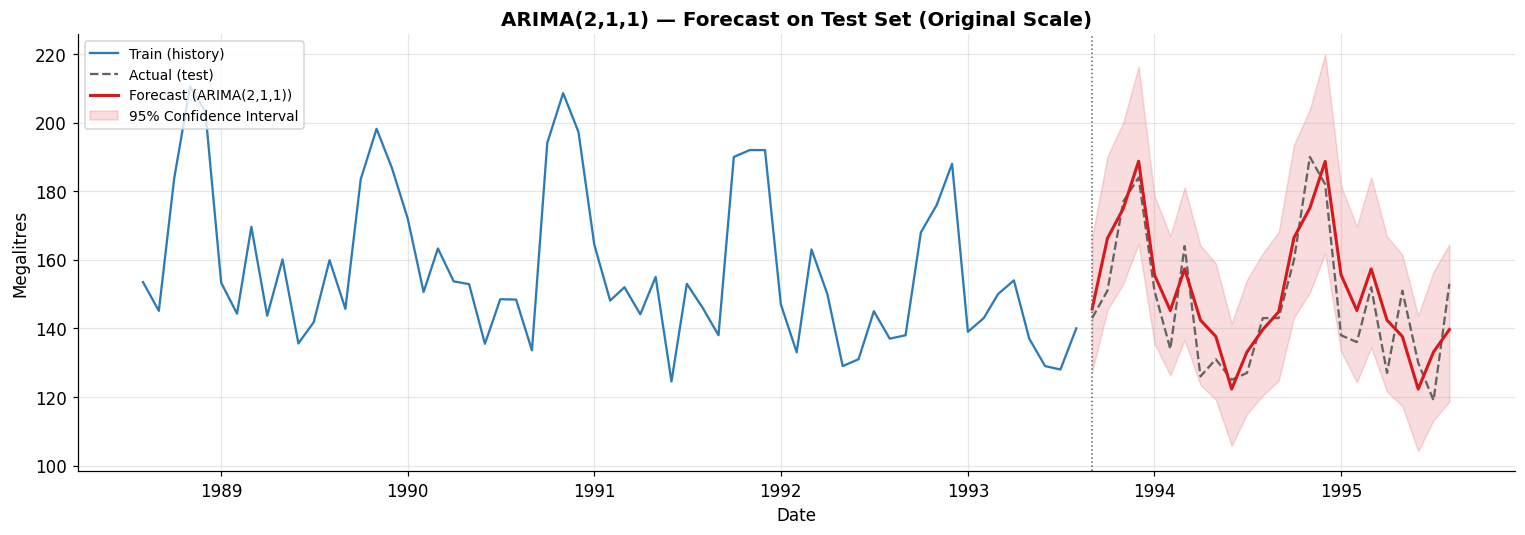


Forecast vs Actual (first 12 months):
            Actual  Forecast  Lower_95  Upper_95
Month                                           
1993-09-01   143.0    145.66    127.39    166.54
1993-10-01   151.0    166.25    145.39    190.10
1993-11-01   177.0    174.96    153.00    200.08
1993-12-01   184.0    188.75    164.68    216.35
1994-01-01   151.0    155.63    135.55    178.69
1994-02-01   134.0    145.20    126.30    166.93
1994-03-01   164.0    157.35    136.67    181.15
1994-04-01   126.0    142.39    123.50    164.16
1994-05-01   131.0    137.65    119.22    158.92
1994-06-01   125.0    122.31    105.79    141.41
1994-07-01   127.0    133.12    114.99    154.12
1994-08-01   143.0    139.66    120.47    161.92


In [29]:
# ── Execute Step 11 ──
fc_df = forecast_and_backtransform(
    best_model, train_bc, train, seasonal_comp, test, period=12
)
# fc_df = forecast_and_backtransform(
#     best_model, train_bc, train, bc_lambda, seasonal_comp, test, period=12
# )

plot_forecast(train, test, fc_df, best_label)

print("\nForecast vs Actual (first 12 months):")
compare_fc = pd.DataFrame({
    'Actual'   : test.values[:12],
    'Forecast' : fc_df['Forecast'].values[:12],
    'Lower_95' : fc_df['Lower_95'].values[:12],
    'Upper_95' : fc_df['Upper_95'].values[:12],
}, index=test.index[:12])
print(compare_fc.round(2).to_string())


## Step 12 — Model Evaluation on Test Set

We compute standard forecast accuracy metrics on the **original scale**,
comparing the back-transformed forecasts against the actual test values.

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| MAE | mean(|actual - forecast|) | Average absolute error |
| RMSE | √mean((actual - forecast)²) | Penalises large errors |
| MAPE | mean(|error|/|actual|) × 100 | % error — scale-free |


In [30]:
def evaluate_forecast(actual, forecast, label="Model"):
    """
    Compute MAE, MSE, RMSE, and MAPE for forecast evaluation.

    Parameters
    ----------
    actual   : array-like — Actual values (test set)
    forecast : array-like — Predicted values
    label    : str        — Model label

    Returns
    -------
    metrics : dict
    """
    actual   = np.array(actual)
    forecast = np.array(forecast)
    errors   = actual - forecast

    mae  = np.mean(np.abs(errors))
    mse  = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs(errors / actual)) * 100

    metrics = {
        'Label' : label,
        'MAE'   : round(mae,  2),
        'MSE'   : round(mse,  2),
        'RMSE'  : round(rmse, 2),
        'MAPE%' : round(mape, 3),
    }

    print("=" * 55)
    print(f"  EVALUATION METRICS — {label}")
    print("=" * 55)
    print(f"  MAE   : {mae:.2f}")
    print(f"  MSE   : {mse:.2f}")
    print(f"  RMSE  : {rmse:.2f}")
    print(f"  MAPE  : {mape:.3f}%")
    print("=" * 55)

    return metrics


In [31]:
# ── Execute Step 12 ──
eval_metrics = evaluate_forecast(test.values, fc_df['Forecast'].values, label=best_label)

# ── Evaluate ALL candidate models (for full comparison) ──
all_eval_rows = []
for label, model in fitted_models.items():
    try:
        fc_temp = forecast_and_backtransform(
            model, train_bc, train, seasonal_comp, test, period=12
        )
        # fc_temp = forecast_and_backtransform(
        #     model, train_bc, train, bc_lambda, seasonal_comp, test, period=12
        # )
        m = evaluate_forecast(test.values, fc_temp['Forecast'].values, label=label)

        # Add AIC, BIC, and LjungBox from comparison_df
        row_info = comparison_df[comparison_df['Label'] == label].iloc[0]
        m['AIC']        = row_info['AIC']
        m['BIC']        = row_info['BIC']
        m['LjungBox_p'] = row_info['LjungBox_p']
        all_eval_rows.append(m)
    except Exception as e:
        print(f"  Could not evaluate {label}: {e}")

eval_df = pd.DataFrame(all_eval_rows).sort_values('RMSE')


  EVALUATION METRICS — ARIMA(2,1,1)
  MAE   : 8.68
  MSE   : 100.59
  RMSE  : 10.03
  MAPE  : 6.080%
  EVALUATION METRICS — ARIMA(1,1,0)
  MAE   : 8.11
  MSE   : 92.83
  RMSE  : 9.64
  MAPE  : 5.654%
  EVALUATION METRICS — ARIMA(0,1,1)
  MAE   : 8.65
  MSE   : 100.64
  RMSE  : 10.03
  MAPE  : 6.056%
  EVALUATION METRICS — ARIMA(1,1,1)
  MAE   : 8.61
  MSE   : 100.02
  RMSE  : 10.00
  MAPE  : 6.031%
  EVALUATION METRICS — ARIMA(2,1,1)
  MAE   : 8.68
  MSE   : 100.59
  RMSE  : 10.03
  MAPE  : 6.080%
  EVALUATION METRICS — ARIMA(2,1,2)
  MAE   : 8.67
  MSE   : 99.69
  RMSE  : 9.98
  MAPE  : 6.080%
  EVALUATION METRICS — ARIMA(3,1,1)
  MAE   : 8.68
  MSE   : 100.06
  RMSE  : 10.00
  MAPE  : 6.083%
  EVALUATION METRICS — ARIMA(2,1,3)
  MAE   : 7.31
  MSE   : 73.88
  RMSE  : 8.60
  MAPE  : 5.093%


## Step 13 — Final Model Comparison & Best Model Selection

We consolidate in-sample fit (AIC, BIC, Ljung-Box) and out-of-sample accuracy
(MAE, RMSE, MAPE) into a single ranked comparison table.


In [32]:
# ── Full Comparison Table ──
print("=" * 80)
print("  FULL MODEL COMPARISON — IN-SAMPLE FIT + OUT-OF-SAMPLE ACCURACY")
print("=" * 80)
display_cols = ['Label', 'AIC', 'BIC', 'LjungBox_p', 'MAE', 'RMSE', 'MAPE%']
print(eval_df[display_cols].to_string(index=False))
print("=" * 80)
print(f"\n  Best Model (lowest RMSE): {eval_df.iloc[0]['Label']}")
print(f"  Note: LjungBox_p must be > 0.05 for residuals to be white noise.")


  FULL MODEL COMPARISON — IN-SAMPLE FIT + OUT-OF-SAMPLE ACCURACY
       Label      AIC      BIC  LjungBox_p  MAE  RMSE  MAPE%
ARIMA(2,1,3) -1201.28 -1176.61      0.9960 7.31  8.60  5.093
ARIMA(1,1,0)  -961.16  -952.93      0.9253 8.11  9.64  5.654
ARIMA(2,1,2) -1136.12 -1115.56      0.9894 8.67  9.98  6.080
ARIMA(1,1,1) -1123.45 -1111.12      0.9901 8.61 10.00  6.031
ARIMA(3,1,1) -1131.84 -1111.28      0.9882 8.68 10.00  6.083
ARIMA(0,1,1) -1120.62 -1112.40      0.9939 8.65 10.03  6.056
ARIMA(2,1,1) -1130.58 -1114.13      0.9851 8.68 10.03  6.080

  Best Model (lowest RMSE): ARIMA(2,1,3)
  Note: LjungBox_p must be > 0.05 for residuals to be white noise.


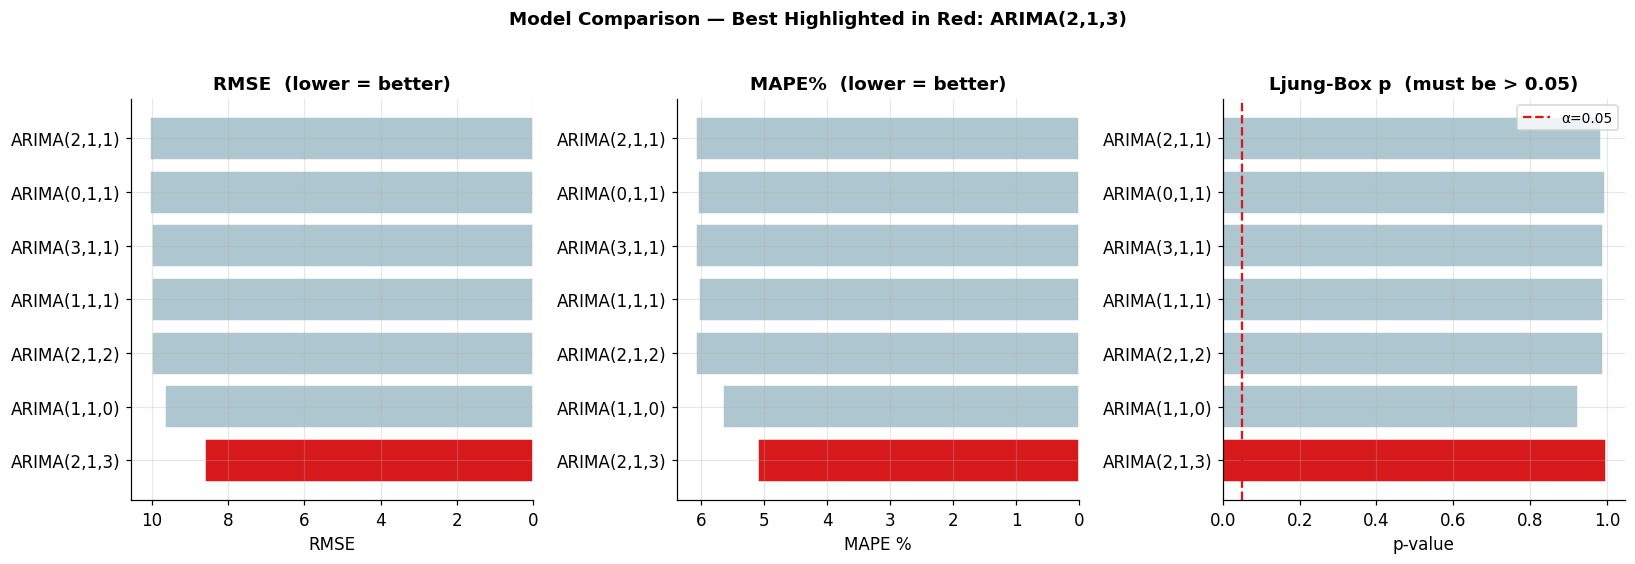

In [33]:
# ── Visualise the full comparison ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

best_rmse_label = eval_df.iloc[0]['Label']
clrs_comp = [COLORS['red'] if l == best_rmse_label else '#aec6cf'
             for l in eval_df['Label']]

axes[0].barh(eval_df['Label'], eval_df['RMSE'], color=clrs_comp, edgecolor='white')
axes[0].set_title("RMSE  (lower = better)", fontweight='bold')
axes[0].set_xlabel("RMSE")
axes[0].invert_xaxis()

axes[1].barh(eval_df['Label'], eval_df['MAPE%'], color=clrs_comp, edgecolor='white')
axes[1].set_title("MAPE%  (lower = better)", fontweight='bold')
axes[1].set_xlabel("MAPE %")
axes[1].invert_xaxis()

axes[2].barh(eval_df['Label'], eval_df['LjungBox_p'], color=clrs_comp, edgecolor='white')
axes[2].axvline(0.05, color=COLORS['red'], linestyle='--', linewidth=1.5, label='α=0.05')
axes[2].set_title("Ljung-Box p  (must be > 0.05)", fontweight='bold')
axes[2].set_xlabel("p-value")
axes[2].legend(fontsize=9)

plt.suptitle(f"Model Comparison — Best Highlighted in Red: {best_rmse_label}",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Final Summary

### Complete Pipeline Recap

| Step | Action | Tool / Test | Purpose |
|------|--------|------------|---------|
| 1 | Load & Explore | Pandas, bar chart | Understand structure |
| 2 | Train-Test Split | 80/20 temporal | Honest evaluation |
| 3 | Deseasonalise | Multiplicative decomposition | Remove seasonal pattern |
| 4 | Box-Cox Transform | scipy.boxcox | Stabilise variance |
| 5 | Differencing (d=1) | .diff() | Remove trend, achieve stationarity |
| 6 | ADF Test | statsmodels.adfuller | Confirm stationarity |
| 7 | Breusch-Pagan Test | het_breuschpagan | Confirm variance stability |
| 8 | ACF / PACF | plot_acf, plot_pacf | Identify candidate orders |
| 9 | Fit ARIMA candidates | sm.tsa.ARIMA | Generate candidate models |
| 10 | Residual Diagnostics | Ljung-Box, QQ, ACF | Validate best model |
| 11 | Forecast on Test | get_forecast + back-transform | Out-of-sample prediction |
| 12 | Evaluate | MAE, RMSE, MAPE | Measure accuracy |
| 13 | Select Best | Full comparison table | Final recommendation |

  FINAL MODEL SELECTION
  Best Model    : ARIMA(2,1,3)
  AIC           : -1201.28
  BIC           : -1176.61
  Ljung-Box p   : 0.996  ✓
  MAE           : 7.31
  RMSE          : 8.6
  MAPE          : 5.093%

  Preprocessing pipeline applied:
  ADF confirmed stationarity after differencing.
  Breusch-Pagan confirmed variance stability after Log.
  Residuals of ARIMA(2,1,3) are white noise (LB p > 0.05) ✓


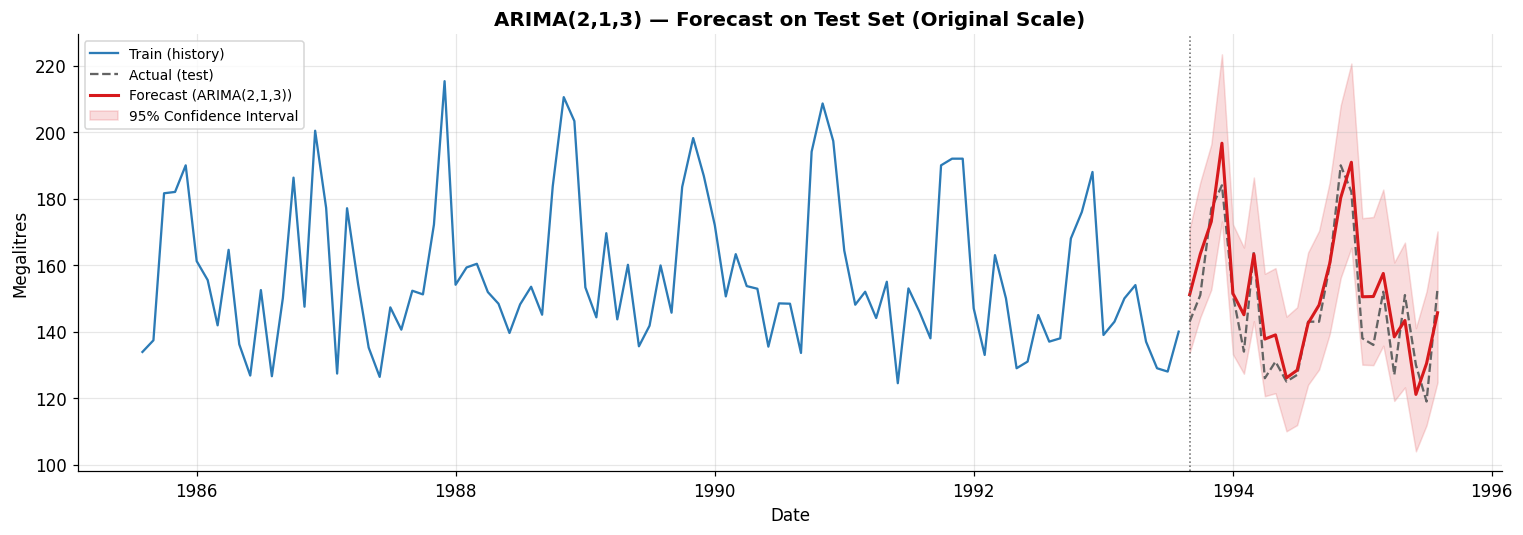

In [34]:
# ── Final Best Model Summary ──
final_best  = eval_df.iloc[0]
print("=" * 60)
print("  FINAL MODEL SELECTION")
print("=" * 60)
print(f"  Best Model    : {final_best['Label']}")
print(f"  AIC           : {final_best['AIC']}")
print(f"  BIC           : {final_best['BIC']}")
print(f"  Ljung-Box p   : {final_best['LjungBox_p']}  {'✓' if final_best['LjungBox_p'] > 0.05 else '✗'}")
print(f"  MAE           : {final_best['MAE']}")
print(f"  RMSE          : {final_best['RMSE']}")
print(f"  MAPE          : {final_best['MAPE%']}%")
print("=" * 60)
print(f"\n  Preprocessing pipeline applied:")
# print(f"  Raw → Deseasonalise → Log) → d=1 Difference → ARIMA")
print(f"  ADF confirmed stationarity after differencing.")
print(f"  Breusch-Pagan confirmed variance stability after Log.")
print(f"  Residuals of {final_best['Label']} are white noise (LB p > 0.05) ✓")

# Final forecast plot for best overall model
final_model = fitted_models[final_best['Label']]
fc_final = forecast_and_backtransform(
    final_model, train_bc, train, seasonal_comp, test, period=12
)
# fc_final = forecast_and_backtransform(
#     final_model, train_bc, train, bc_lambda, seasonal_comp, test, period=12
# )
plot_forecast(train, test, fc_final, final_best['Label'], context_years=8)
